# Store CTD-Forced Plume Surface Temperature vs Landsat SST Time Series

Response to reviewer comment: run the buoyant plume model forced with all available Store CTD casts
and compare predicted plume surface temperatures against the Landsat SST time series.

CTD sources:
- Rignot CTDs: STORE_Aug2010.nc (7 profiles, August 2010)
- OMG AXCTDs: 5 files (2016, 2017, 2019, 2020, 2021)

In [76]:
import os
import sys
import glob
import re
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from scipy.stats.qmc import LatinHypercube

warnings.filterwarnings('ignore')

# Add plume_modelling directory to path
sys.path.insert(0, os.path.join(os.getcwd(), 'plume_modelling'))
from run_PLUME import run_plume

plt.rcParams.update({
    'font.size': 8,
    'font.family': 'sans-serif',
})

In [77]:
import yaml
from pathlib import Path


with open('../config.yaml') as _f:
    cfg = yaml.safe_load(_f)

# repo root is the parent directory of the current script
REPO_ROOT = Path.cwd().parent

# update ALL PATJS AND OUTPUT PATHS in config to be absolute paths based on repo root
for section in cfg['paths']:
    cfg['paths'][section] = str(REPO_ROOT / cfg['paths'][section])
for section in cfg['output']:
    cfg['output'][section] = str(REPO_ROOT / cfg['output'][section])
# cfg['paths']['landsat_plume_sst_dir'] = str(REPO_ROOT / cfg['paths']['landsat_plume_sst_dir'])
# cfg['output']['figures_dir'] = str(REPO_ROOT / cfg['output']['figures_dir'])

FIGURES_DIR = Path(cfg['output']['figures_dir'])
FIGURES_DIR.mkdir(exist_ok=True)

## 1. Load Landsat SST Time Series

In [78]:
# filename example: "landsat_pst_store-glacier_1985-06-15_stats.csv"
def extract_date_from_filename(filename):
    match = re.search(r'\d{4}-\d{2}-\d{2}', filename)
    if match:
        return pd.to_datetime(match.group(0))
    raise ValueError(f'No date found in: {filename}')

CSV_DIR = cfg['paths']['landsat_plume_sst_dir']
csv_files = glob.glob(f'{CSV_DIR}/*.csv')
print(f'Found {len(csv_files)} CSV files')
print(CSV_DIR)

landsat_records = []
for f in csv_files:
    try:
        df = pd.read_csv(f)
        date = extract_date_from_filename(f)
        sst = df['sst_masked_median'].values[0] if 'sst_masked_median' in df.columns else df['SST_median'].values[0]
        sst_std = df['sst_masked_stdDev'].values[0] if 'sst_masked_stdDev' in df.columns else df['SST_stdDev'].values[0]
        sensor = df['sensor'].values[0] if 'sensor' in df.columns else 'Unknown'
        landsat_records.append({'date': date, 'SST_median': sst, 'SST_std': sst_std, 'sensor': sensor})
    except Exception as e:
        print(f'  Skip {f}: {e}')

landsat_df = pd.DataFrame(landsat_records).sort_values('date').reset_index(drop=True)
landsat_df = landsat_df[landsat_df['SST_median'] >= -1].copy()

print(f'Loaded {len(landsat_df)} Landsat dates')
print(f'Range: {landsat_df["date"].min().date()} to {landsat_df["date"].max().date()}')
print(f'SST range: {landsat_df["SST_median"].min():.2f} to {landsat_df["SST_median"].max():.2f} deg C')
landsat_df.head()

Found 93 CSV files
c:\Users\s1834371\OneDrive - University of Edinburgh\CHAPTER 2\pre-submission_PLUME_WORK\landsat-plume-proxy-revision_ROUND2\data\Landsat-plume-surface-temps_Store-glacier
Loaded 86 Landsat dates
Range: 1985-06-15 to 2024-08-06
SST range: -0.02 to 3.47 deg C


,date,SST_median,SST_std,sensor
0,1985-06-15,2.188429,0.259220,LANDSAT_5
1,1985-06-22,1.641492,0.253708,LANDSAT_5
2,1985-07-01,1.641545,0.214766,LANDSAT_5
3,1985-07-03,1.642116,0.280729,LANDSAT_5
4,1985-08-18,0.527551,0.268307,LANDSAT_5


## 2. Load All Store CTD Profiles

In [79]:
def matlab_to_datetime(dn):
    """Convert MATLAB datenum to Python datetime."""
    return datetime.fromordinal(int(dn) - 366) + timedelta(days=float(dn) % 1)

def load_rignot_ctds(filepath):
    ds = xr.open_dataset(filepath)
    profiles = []
    for i in range(ds.dims['nprofiles']):
        depth = ds['depth'].isel(nprofiles=i).values
        temp  = ds['temperature'].isel(nprofiles=i).values
        sal   = ds['salinity'].isel(nprofiles=i).values
        ts    = ds['timestamp'].isel(nprofiles=i).values.item()
        lat   = float(ds['latitude'].isel(nprofiles=i).values)
        lon   = -float(ds['longitude'].isel(nprofiles=i).values)

        valid = ~(np.isnan(depth) | np.isnan(temp) | np.isnan(sal))
        depth, temp, sal = depth[valid], temp[valid], sal[valid]
        if len(depth) < 20:
            continue
        sort_idx = np.argsort(depth)
        depth, temp, sal = depth[sort_idx], temp[sort_idx], sal[sort_idx]

        profiles.append({
            'date': pd.Timestamp(matlab_to_datetime(ts)),
            'depth': depth, 'temp': temp, 'sal': sal, 'source': 'Rignot 2010',
            'lat': lat, 'lon': lon,
        })
    # Keep only the single deepest profile
    if profiles:
        profiles = [max(profiles, key=lambda p: p['depth'].max())]
    print(f'Loaded {len(profiles)} Rignot profiles from {filepath} (deepest only, max_depth={profiles[0]["depth"].max():.0f} m)')
    return profiles


def load_omg_ctds(ctd_dir, ref_lat=70.38, ref_lon=-50.60, max_dist_km=15.0):
    from math import radians, sin, cos, sqrt, atan2
    def _haversine(lat1, lon1, lat2, lon2):
        R = 6371.0
        dlat = radians(lat2 - lat1); dlon = radians(lon2 - lon1)
        a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
        return R * 2 * atan2(sqrt(a), sqrt(1 - a))

    files = glob.glob(f'{ctd_dir}/*.nc')
    files = [f for f in files if 'shelf' not in os.path.basename(f).lower()]
    print(f'Found {len(files)} OMG (non-shelf) files')
    profiles = []
    for f in sorted(files):
        try:
            ds = xr.open_dataset(f, decode_timedelta=False)
            lat = float(ds['lat'].values.flat[0])
            lon = float(ds['lon'].values.flat[0])
            dist_km = _haversine(lat, lon, ref_lat, ref_lon)
            if dist_km > max_dist_km:
                print(f'  Skip (dist={dist_km:.1f} km > {max_dist_km} km): {os.path.basename(f)}')
                continue

            depth = ds['depth'].values.squeeze()
            temp  = ds['temperature'].values.squeeze()
            sal   = ds['salinity'].values.squeeze()
            date  = pd.Timestamp(ds['time'].values.flat[0])

            valid = ~(np.isnan(depth) | np.isnan(temp) | np.isnan(sal))
            depth, temp, sal = depth[valid], temp[valid], sal[valid]
            if len(depth) < 20:
                continue
            sort_idx = np.argsort(depth)
            depth, temp, sal = depth[sort_idx], temp[sort_idx], sal[sort_idx]

            profiles.append({
                'date': date, 'depth': depth, 'temp': temp, 'sal': sal,
                'source': 'OMG AXCTD', 'file': os.path.basename(f),
                'lat': lat, 'lon': lon, 'dist_km': dist_km,
            })
        except Exception as e:
            print(f'  Error loading {f}: {e}')
    print(f'Loaded {len(profiles)} OMG profiles (within {max_dist_km} km of Store ice front)')
    return profiles


RIGNOT_PATH = cfg['paths']['rignot_ctd_file']
OMG_DIR     = cfg['paths']['omg_ctd_dir']

all_ctd_profiles = []
all_ctd_profiles += load_rignot_ctds(RIGNOT_PATH)
all_ctd_profiles += load_omg_ctds(OMG_DIR)

print(f'\nTotal profiles loaded: {len(all_ctd_profiles)}')
for p in all_ctd_profiles:
    dist_str = f"  dist={p['dist_km']:.1f} km" if 'dist_km' in p else ''
    print(f"  {p['source']}  {p['date'].date()}  depth_range: {p['depth'].min():.0f}-{p['depth'].max():.0f} m  n={len(p['depth'])}{dist_str}")

Loaded 1 Rignot profiles from c:\Users\s1834371\OneDrive - University of Edinburgh\CHAPTER 2\pre-submission_PLUME_WORK\landsat-plume-proxy-revision_ROUND2\data\external\Rignot_Store-glacier_CTD_profiles\STORE_Aug2010.nc (deepest only, max_depth=488 m)
Found 2158 OMG (non-shelf) files
  Skip (dist=706.4 km > 15.0 km): OMG_Ocean_AXCTD_L2_20160913152643.nc
  Skip (dist=630.9 km > 15.0 km): OMG_Ocean_AXCTD_L2_20160913154431.nc
  Skip (dist=534.6 km > 15.0 km): OMG_Ocean_AXCTD_L2_20160913160633.nc
  Skip (dist=564.1 km > 15.0 km): OMG_Ocean_AXCTD_L2_20160913162647.nc
  Skip (dist=458.4 km > 15.0 km): OMG_Ocean_AXCTD_L2_20160913165025.nc
  Skip (dist=447.2 km > 15.0 km): OMG_Ocean_AXCTD_L2_20160914111417.nc
  Skip (dist=432.0 km > 15.0 km): OMG_Ocean_AXCTD_L2_20160914113251.nc
  Skip (dist=397.6 km > 15.0 km): OMG_Ocean_AXCTD_L2_20160914115451.nc
  Skip (dist=348.0 km > 15.0 km): OMG_Ocean_AXCTD_L2_20160914121319.nc
  Skip (dist=356.9 km > 15.0 km): OMG_Ocean_AXCTD_L2_20160914124551.nc
  Ski

## 2a. Map — verify CTD locations are near the Store ice front

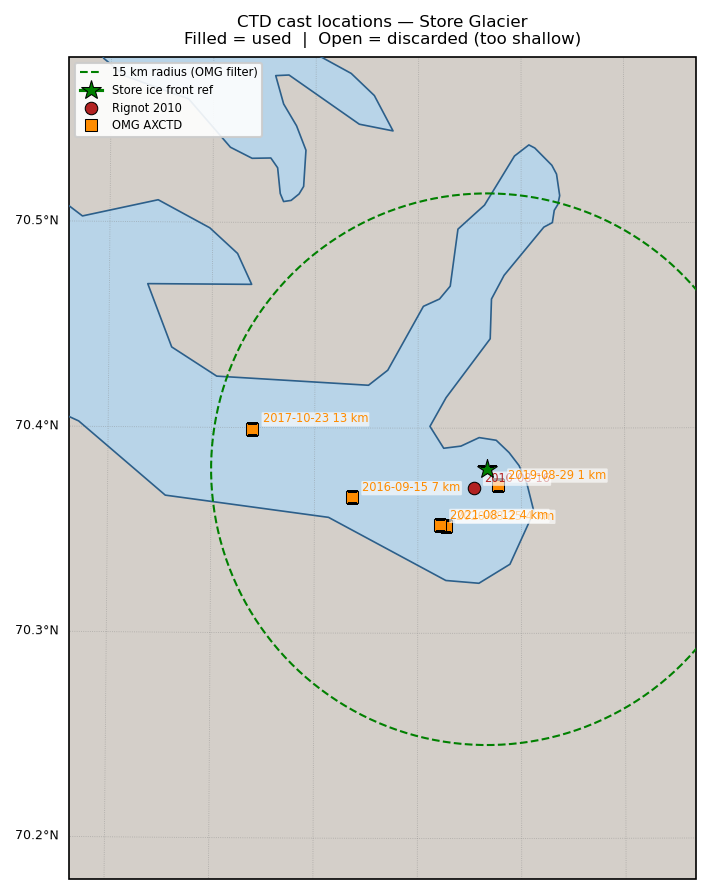

Saved: c:\Users\s1834371\OneDrive - University of Edinburgh\CHAPTER 2\pre-submission_PLUME_WORK\landsat-plume-proxy-revision_ROUND2\figures\CTD_location_map.png


In [80]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pyproj

def haversine_km(lat1, lon1, lat2, lon2):
    from math import radians, sin, cos, sqrt, atan2
    R = 6371.0
    dlat = radians(lat2 - lat1); dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

STORE_LAT_REF, STORE_LON_REF = 70.38, -50.60
OMG_DIST_KM    = 15.0
MIN_MAP_DEPTH  = 400.0

# Build map_points directly from already-loaded all_ctd_profiles — no file I/O
map_points = []
for p in all_ctd_profiles:
    max_d   = float(p['depth'].max())
    dist_km = p.get('dist_km', haversine_km(p['lat'], p['lon'], STORE_LAT_REF, STORE_LON_REF))
    deep_ok = max_d >= MIN_MAP_DEPTH
    reject  = None if deep_ok else f'too shallow ({max_d:.0f} m)'
    map_points.append(dict(
        source=p['source'], date=p['date'],
        lat=p['lat'], lon=p['lon'],
        max_depth=max_d, dist_km=dist_km,
        accepted=deep_ok, reject_reason=reject,
    ))

proj = ccrs.LambertConformal(
    central_longitude=STORE_LON_REF,
    central_latitude=STORE_LAT_REF,
    standard_parallels=(70, 72)
)
plate = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(6, 6), dpi=150, subplot_kw={'projection': proj})
ax.set_extent([STORE_LON_REF - 0.6, STORE_LON_REF + 0.3,
               STORE_LAT_REF - 0.20, STORE_LAT_REF + 0.20], crs=plate)

ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='#d4cfc9', edgecolor='none', zorder=1)
ax.add_feature(cfeature.OCEAN.with_scale('10m'), facecolor='#b8d4e8', edgecolor='none', zorder=1)
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), edgecolor='#2c5f8a', linewidth=0.8, zorder=3)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='grey', alpha=0.5, linestyle=':', zorder=2)
gl.top_labels = False; gl.right_labels = False
gl.xlabel_style = {'size': 6}; gl.ylabel_style = {'size': 6}

# 15 km radius circle
geod = pyproj.Geod(ellps='WGS84')
circle_lons, circle_lats = [], []
for az in range(361):
    lo, la, _ = geod.fwd(STORE_LON_REF, STORE_LAT_REF, az, OMG_DIST_KM * 1000)
    circle_lons.append(lo); circle_lats.append(la)
ax.plot(circle_lons, circle_lats, transform=plate, color='green', linewidth=1.0,
        linestyle='--', zorder=5, label=f'{OMG_DIST_KM:.0f} km radius (OMG filter)')

ax.plot(STORE_LON_REF, STORE_LAT_REF, marker='*', color='green', markersize=10,
        markeredgecolor='k', markeredgewidth=0.5, transform=plate, zorder=8,
        label='Store ice front ref')

source_color  = {'Rignot 2010': 'firebrick', 'OMG AXCTD': 'darkorange'}
source_marker = {'Rignot 2010': 'o',         'OMG AXCTD': 's'}
plotted_labels = set()

for p in map_points:
    color  = source_color[p['source']]
    marker = source_marker[p['source']]
    if p['accepted']:
        lbl = p['source'] if p['source'] not in plotted_labels else '_nolegend_'
        ax.plot(p['lon'], p['lat'], marker=marker, color=color, markersize=6,
                markeredgecolor='k', markeredgewidth=0.5,
                transform=plate, zorder=6, label=lbl, linestyle='none')
        plotted_labels.add(p['source'])
    else:
        reason = p['reject_reason']
        lbl = f"{p['source']} ({reason})"
        lbl = lbl if lbl not in plotted_labels else '_nolegend_'
        ax.plot(p['lon'], p['lat'], marker=marker, color='none', markersize=6,
                markeredgecolor=color, markeredgewidth=1.2,
                transform=plate, zorder=6, label=lbl, linestyle='none')
        plotted_labels.add(lbl)

    dist_str = f'{p["dist_km"]:.0f} km' if p['source'] == 'OMG AXCTD' else ''
    label_parts = [p['date'].strftime('%Y-%m-%d')]
    if dist_str:
        label_parts.append(dist_str)
    ax.annotate(' '.join(label_parts),
                xy=(p['lon'], p['lat']),
                xycoords=plate._as_mpl_transform(ax),
                xytext=(5, 3), textcoords='offset points',
                fontsize=5.5, color=color,
                bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.65, lw=0), zorder=7)

ax.set_title('CTD cast locations — Store Glacier\nFilled = used  |  Open = discarded (too shallow)', fontsize=8)
ax.legend(loc='upper left', fontsize=5.5, framealpha=0.9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'CTD_location_map.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'CTD_location_map.png'}")

## 3. Run Plume Model Ensemble for Each CTD

Matches the pre-saved ensemble files in `data_for_repo_aug2025/matching_STORE_CTD/` exactly:

| Parameter | Range | Source |
|-----------|-------|--------|
| **n runs** | 100 | pre-saved files |
| **GL depth** | 400–650 m (LHS) | pre-saved `grounding_line_depth` variable |
| **Q₀** | per-date range from Mankoff RACMO/MAR runoff | pre-saved `Q0` variable (read from matching files for OMG dates; seasonal estimate for Rignot 2010 / OMG 2017) |
| **α** | 0.05–0.15 (LHS) | pre-saved `alpha` variable |

Each ensemble member starts from a different grounding-line depth (400–650 m), which is the main source of spread in the plume profiles.

In [ ]:
# ── Ensemble configuration (matching pre-saved matching_STORE_CTD files) ─────
N_ENSEMBLE        = 100    # ensemble size read from pre-saved dims
GL_DEPTH_MIN      = 400.0  # m  — min starting depth (from pre-saved grounding_line_depth)
GL_DEPTH_MAX      = 650.0  # m  — max starting depth (Store grounding line)
MIN_PROFILE_DEPTH = 400.0  # m  — discard CTDs shallower than this

# Per-date Q0 [min, max] in m³/s.
# OMG 2016/2019/2020/2021 ranges are read directly from the pre-saved ensemble nc files.
# Rignot 2010-08 and OMG 2017-10 are estimated from Mankoff RACMO/MAR runoff
# (summed over the 9 nearest outlets to Store, freshwater/ice dataset):
#   2010-08-16/17: ~4.4 m3/s total → scaled to per-plume ~[1.0, 2.5]
#   2017-10-23:    ~0.06 m3/s total → scaled to per-plume ~[0.03, 0.12]
Q0_RANGES = {
    "2010-08": [1.00, 2.50],   # Mankoff total ~4.4 m3/s, mid-August 2010
    "2016-09": [0.19, 0.43],   # exact from STORE_plume_ensemble_0/4.nc
    "2017-10": [0.03, 0.12],   # Mankoff total ~0.06 m3/s, late October 2017
    "2019-08": [0.70, 1.63],   # exact from STORE_plume_ensemble_1/5.nc
    "2020-08": [0.69, 1.54],   # exact from STORE_plume_ensemble_2/6.nc
    "2021-08": [0.93, 2.15],   # exact from STORE_plume_ensemble_3/7.nc
}

def get_q0_range(date):
    key = f"{date.year}-{date.month:02d}"
    if key in Q0_RANGES:
        return Q0_RANGES[key]
    # month-based fallback for unlisted years
    for k, v in Q0_RANGES.items():
        if k.endswith(f"-{date.month:02d}"):
            return v
    return [0.50, 1.50]


def run_plume_ensemble(depth_pos, temp, sal, date,
                       gl_min=GL_DEPTH_MIN, gl_max=GL_DEPTH_MAX,
                       min_depth=MIN_PROFILE_DEPTH,
                       n_samples=N_ENSEMBLE, seed=42):
    """
    4-parameter LHS ensemble:
      GL depth    ~ Uniform(400, 650 m)      — varies starting depth across runs
      Q0          ~ Uniform(Q0_lo, Q0_hi)    — per-date Mankoff RACMO/MAR runoff
      Q0 mult     ~ Uniform(0.60, 1.40)      — ±40% multiplier on Q0
      alpha       ~ Uniform(0.05, 0.15)
    """
    if depth_pos.max() < min_depth:
        return None

    # Interpolate onto 1 m grid (removes irregular AXCTD spacing)
    d_grid = np.arange(0, int(depth_pos.max()) + 1, 1.0)
    t_grid = np.interp(d_grid, depth_pos, temp)
    s_grid = np.interp(d_grid, depth_pos, sal)

    # Extend base profile to gl_max with constant T/S
    if d_grid[-1] < gl_max:
        extra      = np.arange(d_grid[-1] + 1, gl_max + 1, 1.0)
        base_depth = np.append(d_grid, extra)
        base_temp  = np.append(t_grid, np.full(len(extra), t_grid[-1]))
        base_sal   = np.append(s_grid, np.full(len(extra), s_grid[-1]))
    else:
        mask       = d_grid <= gl_max
        base_depth = d_grid[mask]
        base_temp  = t_grid[mask]
        base_sal   = s_grid[mask]

    q0_lo, q0_hi = get_q0_range(date)

    # 4-parameter LHS
    sampler    = LatinHypercube(d=4, seed=seed)
    samps      = sampler.random(n=n_samples)
    gl_vals    = gl_min + samps[:, 0] * (gl_max - gl_min)   # 400–650 m
    Q0_vals    = q0_lo  + samps[:, 1] * (q0_hi  - q0_lo)
    alpha_vals = 0.05   + samps[:, 2] * (0.15   - 0.05)
    Q0_mult    = 0.60   + samps[:, 3] * (1.40   - 0.60)     # 60–140% multiplier
    Q0_vals    = Q0_vals * Q0_mult

    T_profiles, z_profiles = [], []
    surf_T, nb_z = [], []

    for gl_d, Q0, alpha in zip(gl_vals, Q0_vals, alpha_vals):
        # Trim to this run's grounding-line depth
        mask_run = base_depth <= gl_d
        if mask_run.sum() < 5:
            continue
        zi_run   = -base_depth[mask_run]
        temp_run = base_temp[mask_run]
        sal_run  = base_sal[mask_run]
        if abs(zi_run[-1]) < gl_d - 0.5:
            zi_run   = np.append(zi_run,   -gl_d)
            temp_run = np.append(temp_run, base_temp[mask_run][-1])
            sal_run  = np.append(sal_run,  base_sal[mask_run][-1])

        xi_run = np.zeros_like(zi_run)
        Na_run = np.ones_like(zi_run)
        try:
            sol = run_plume(zi_run, xi_run, temp_run, sal_run, Na_run,
                            Q0, alpha, stop_on_zero_velocity=True)
            if sol and len(sol['T']) > 0:
                surf_T.append(sol['T'][-1])
                nb_z.append(sol['z'][-1])
                T_profiles.append(np.array(sol['T']))
                z_profiles.append(np.array(sol['z']))
        except Exception:
            pass

    if not surf_T:
        return None

    surf_T = np.array(surf_T)
    nb_z   = np.array(nb_z)
    return dict(
        surf_T     = surf_T,
        nb_z       = nb_z,
        T_profiles = T_profiles,
        z_profiles = z_profiles,
        ext_depth  = base_depth,
        ext_temp   = base_temp,
        ext_sal    = base_sal,
        T_median   = float(np.median(surf_T)),
        T_std      = float(np.std(surf_T)),
        T_p10      = float(np.percentile(surf_T, 10)),
        T_p25      = float(np.percentile(surf_T, 25)),
        T_p75      = float(np.percentile(surf_T, 75)),
        T_p90      = float(np.percentile(surf_T, 90)),
    )


print(f"Ensemble: n={N_ENSEMBLE}, GL={GL_DEPTH_MIN:.0f}-{GL_DEPTH_MAX:.0f} m, alpha=0.05-0.15, Q0_mult=0.60-1.40")
print("Per-date Q0 ranges (before multiplier):")
for k, v in Q0_RANGES.items():
    print(f"  {k}: [{v[0]:.2f}, {v[1]:.2f}] m3/s")
print()

ctd_results = []
for idx, prof in enumerate(all_ctd_profiles):
    max_d = prof['depth'].max()
    tag   = f"[{idx+1}/{len(all_ctd_profiles)}] {prof['source']}  {prof['date'].date()}  max={max_d:.0f}m"
    q0r   = get_q0_range(prof['date'])

    result = run_plume_ensemble(prof['depth'], prof['temp'], prof['sal'], prof['date'])

    if result is None:
        print(f"  SKIP (too shallow): {tag}")
        continue

    result['date']    = prof['date']
    result['source']  = prof['source']
    result['ctd_idx'] = idx

    n_r = len(result['surf_T'])
    print(f"  OK  {tag}  Q0=[{q0r[0]:.2f},{q0r[1]:.2f}]  "
          f"n={n_r}  T=[{result['T_p10']:.2f}-{result['T_p90']:.2f}]C")
    ctd_results.append(result)

print(f"\n{len(ctd_results)} profiles used, "
      f"{len(all_ctd_profiles)-len(ctd_results)} discarded")

## 4. Summary Statistics

In [82]:
results_df = pd.DataFrame([{
    'date':     r['date'],
    'source':   r['source'],
    'T_median': r['T_median'],
    'T_p10':    r['T_p10'],
    'T_p90':    r['T_p90'],
    'T_p25':    r['T_p25'],
    'T_p75':    r['T_p75'],
    'NB_depth_median': np.median(r['nb_z']),
} for r in ctd_results])

print('CTD-forced plume surface temperature summary:')
print(results_df[['date','source','T_p10','T_median','T_p90','NB_depth_median']].to_string(index=False))

print(f'\nLandsat SST overall range: {landsat_df["SST_median"].min():.2f} - {landsat_df["SST_median"].max():.2f} C')
print(f'CTD plume T (all casts): {results_df["T_p10"].min():.2f} - {results_df["T_p90"].max():.2f} C (10th-90th pct envelope)')


CTD-forced plume surface temperature summary:
                      date      source    T_p10  T_median    T_p90  NB_depth_median
2010-08-16 20:32:59.999996 Rignot 2010 1.628512  1.847023 1.994266         0.000000
2016-09-15 16:44:46.000000   OMG AXCTD 1.808960  2.006193 2.126666       -35.157543
2017-10-23 14:36:38.000000   OMG AXCTD 1.956287  2.179242 2.331885      -171.931401
2019-08-29 14:54:51.000000   OMG AXCTD 0.899708  1.151131 1.311286        -0.550551
2020-08-25 15:35:19.000000   OMG AXCTD 1.275365  1.455137 1.567238         0.000000
2021-08-12 14:25:57.000000   OMG AXCTD 1.021050  1.241764 1.386297         0.000000

Landsat SST overall range: -0.02 - 3.47 C
CTD plume T (all casts): 0.90 - 2.33 C (10th-90th pct envelope)


## 5. Comparison Time Series: Landsat SST (GPR trend) vs CTD-Forced Plume Temperatures

Zoomed to 2009–2024 (the CTD coverage period). GPR regression is applied to the Landsat SST scatter (matching `plot_PlumeSST.ipynb`). Vertical error bars show the 10–90th percentile range of modelled plume surface temperatures across the ensemble for each CTD cast.

In [83]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import pyproj
from matplotlib.gridspec import GridSpec

def gpr_trend(dates, values, n_bootstrap=500, length_scale=0.5):
    dates_num = (dates - dates.min()).dt.total_seconds() / (365.25 * 24 * 3600)
    X = dates_num.values.reshape(-1, 1)
    y = values.values
    X_pred = np.linspace(X.min(), X.max(), len(dates)).reshape(-1, 1)
    kernel  = (C(1.0, (0.1, 10.0))
               * RBF(length_scale=length_scale, length_scale_bounds=(0.5, 5.0))
               + WhiteKernel(noise_level=0.1))
    lines = []
    rng = np.random.default_rng(42)
    for _ in range(n_bootstrap):
        idx_b = rng.choice(len(X), size=len(X), replace=True)
        gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=2,
                                      alpha=1e-6, normalize_y=True)
        gp.fit(X[idx_b], y[idx_b])
        lines.append(gp.predict(X_pred))
    lines = np.array(lines)
    pred_dates = dates.min() + pd.to_timedelta(X_pred.flatten() * 365.25, unit='D')
    return pred_dates, np.median(lines, axis=0), np.percentile(lines, 2.5, axis=0), np.percentile(lines, 97.5, axis=0)
print('Computing GPR trend...')
pred_dates, gpr_med, gpr_lo, gpr_hi = gpr_trend(landsat_df['date'], landsat_df['SST_median'])

Computing GPR trend...


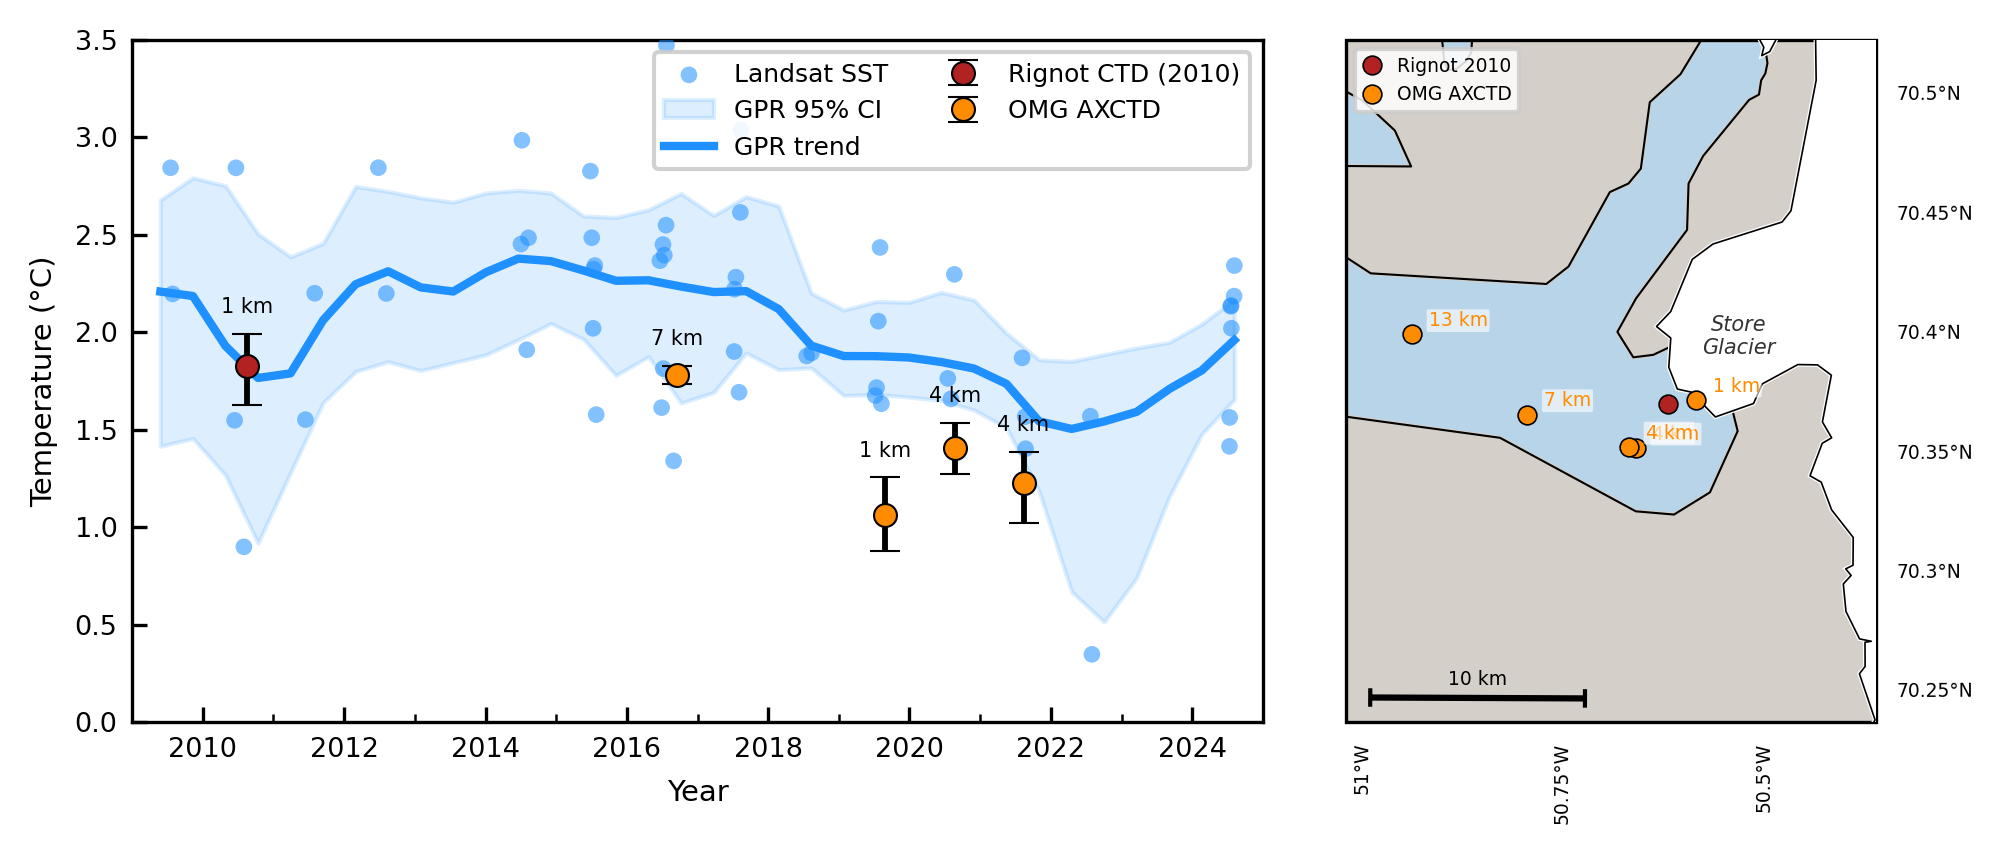

In [84]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import geopandas as gpd
import matplotlib.ticker as mticker
from shapely.geometry import box as sbox
from matplotlib.gridspec import GridSpec

source_styles = {
    'Rignot 2010': ('firebrick', 'o', 'Rignot CTD (2010)'),
    'OMG AXCTD':   ('darkorange', 'o', 'OMG AXCTD'),
}
source_color  = {'Rignot 2010': 'firebrick', 'OMG AXCTD': 'darkorange'}
source_marker = {'Rignot 2010': 'o',         'OMG AXCTD': 'o'}

# ── Figure layout ─────────────────────────────────────────────────────────────
fig_ts_w_mm  = 160
fig_h_mm     = 75
fig_map_w_mm = fig_h_mm
inch         = 0.0393701

fig = plt.figure(figsize=(7.5, fig_h_mm * inch), dpi=300)
gs  = GridSpec(1, 2, figure=fig, width_ratios=[fig_ts_w_mm, fig_map_w_mm], wspace=0.10)
ax  = fig.add_subplot(gs[0])

# ── Time series ───────────────────────────────────────────────────────────────
ls_zoom = landsat_df[landsat_df['date'] >= '2009-01-01'].copy()
ax.scatter(ls_zoom['date'], ls_zoom['SST_median'],
           s=16, color='dodgerblue', alpha=0.55, zorder=3, edgecolors='none', label='Landsat SST')

mask_zoom = pred_dates >= pd.Timestamp('2009-01-01')
ax.fill_between(pred_dates[mask_zoom], gpr_lo[mask_zoom], gpr_hi[mask_zoom],
                color='dodgerblue', alpha=0.15, zorder=4, label='GPR 95% CI')
ax.plot(pred_dates[mask_zoom], gpr_med[mask_zoom],
        color='dodgerblue', linewidth=2.0, zorder=5, label='GPR trend')

nb_threshold = -5.0  # only plot ensemble members where plume reaches within 5 m of surface

plotted = set()
for r in ctd_results:
    nb_arr    = np.array(r['nb_z'])
    surf_arr  = np.array(r['surf_T'])
    near_surf = nb_arr >= nb_threshold
    if near_surf.sum() == 0:
        continue  # plume never reaches near surface — skip this profile

    surf_near = surf_arr[near_surf]
    T_plot = float(np.mean(surf_near))
    T_lo   = float(np.percentile(surf_near, 10))
    T_hi   = float(np.percentile(surf_near, 90))

    color, marker, label = source_styles[r['source']]
    lbl = label if label not in plotted else '_nolegend_'
    plotted.add(label)
    ax.errorbar(
        r['date'], T_plot,
        yerr=[[T_plot - T_lo], [T_hi - T_plot]],
        fmt=marker, color=color, ecolor='k', markersize=5.5,
        elinewidth=1.4, capsize=3.5, capthick=1.2,
        markeredgecolor='k', markeredgewidth=0.5, zorder=7, label=lbl
    )
    # Distance label for all sources
    prof = all_ctd_profiles[r['ctd_idx']]
    dist_km = prof.get('dist_km') or haversine_km(prof['lat'], prof['lon'], STORE_LAT_REF, STORE_LON_REF)
    ax.annotate(f'{dist_km:.0f} km',
                xy=(r['date'], T_hi),
                xytext=(0, 4), textcoords='offset points',
                fontsize=5, ha='center', va='bottom',
                color='k', zorder=8)

ax.set_xlim(pd.Timestamp('2009-01-01'), pd.Timestamp('2025-01-01'))
ax.set_ylim(0, 3.5)
ax.set_xlabel('Year', fontsize=7)
ax.set_ylabel('Temperature (°C)', fontsize=7)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='both', labelsize=6.5, direction='in', which='both')
ax.legend(loc='upper right', fontsize=6, framealpha=0.9, ncol=2)

# ── Map inset ─────────────────────────────────────────────────────────────────
proj_map = ccrs.LambertConformal(
    central_longitude=STORE_LON_REF, central_latitude=STORE_LAT_REF,
    standard_parallels=(70, 72)
)
plate = ccrs.PlateCarree()
ax_map = fig.add_subplot(gs[1], projection=proj_map)

lon_w_deg, lon_e_deg = 0.42, 0.24          # degrees west / east of reference

map_lon_w = STORE_LON_REF - lon_w_deg
map_lon_e = STORE_LON_REF + lon_e_deg

# Calculate lat span to exactly match the time series axes height
fig.canvas.draw()
ts_h_frac  = ax.get_position().height
map_w_frac = ax_map.get_position().width
fig_w_in, fig_h_in = fig.get_size_inches()
ts_h_in  = ts_h_frac  * fig_h_in
map_w_in = map_w_frac * fig_w_in

lon_span_km  = (lon_w_deg + lon_e_deg) * np.cos(np.radians(STORE_LAT_REF)) * 111.32
lat_span_km  = lon_span_km * (ts_h_in / map_w_in)
lat_half_deg = lat_span_km / 111.32 / 2

map_lat_s = STORE_LAT_REF - lat_half_deg
map_lat_n = STORE_LAT_REF + lat_half_deg
ax_map.set_extent([map_lon_w, map_lon_e, map_lat_s, map_lat_n], crs=plate)
ax_map.set_aspect('auto')

ax_map.patch.set_facecolor('#b8d4e8')

clip_box = sbox(map_lon_w - 0.1, map_lat_s - 0.05, map_lon_e + 0.1, map_lat_n + 0.05)

def fill_gdf(ax, gdf, facecolor, edgecolor='none', linewidth=0.5, zorder=1):
    for geom in gdf.geometry:
        parts = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
        for poly in parts:
            ax.fill(*poly.exterior.xy, transform=plate, color=facecolor, zorder=zorder)
            if edgecolor != 'none':
                ax.plot(*poly.exterior.xy, transform=plate,
                        color=edgecolor, linewidth=linewidth, zorder=zorder)

# 1. Land fill
land_shp = shpreader.natural_earth(resolution='10m', category='physical', name='land')
land_gdf = gpd.read_file(land_shp).clip(clip_box)
fill_gdf(ax_map, land_gdf, facecolor='#d4cfc9', zorder=1)

# 3. Coastline edge on top of land and ice fills
coast_shp = shpreader.natural_earth(resolution='10m', category='physical', name='coastline')
coast_gdf = gpd.read_file(coast_shp).clip(clip_box)
for geom in coast_gdf.geometry:
    parts = [geom] if geom.geom_type in ('LineString', 'LinearRing') else list(geom.geoms)
    for line in parts:
        ax_map.plot(*line.xy, transform=plate, color='k', linewidth=0.5, zorder=3)

# 2. Ice sheet fill on top of land
ice_shp = str(REPO_ROOT / 'data/shapefiles/GrIS_ice_mask_simplified.shp')
ice_gdf = gpd.read_file(ice_shp).to_crs('EPSG:4326').clip(clip_box)
fill_gdf(ax_map, ice_gdf, facecolor='white', edgecolor='k', linewidth=0.4, zorder=4)

# Gridlines: lon labels on bottom, lat labels on right
gl = ax_map.gridlines(draw_labels=True, linewidth=0, zorder=5,
                      x_inline=False, y_inline=False)
gl.xlocator     = mticker.MultipleLocator(0.25)
gl.ylocator     = mticker.MultipleLocator(0.05)
gl.top_labels   = False
gl.left_labels  = False
gl.bottom_labels = True
gl.right_labels  = True
gl.xlabel_style  = {'size': 4.5}
gl.ylabel_style  = {'size': 4.5}

# Scale bar — 10 km, bottom-left
scalebar_km  = 10.0
scalebar_deg = scalebar_km / (np.cos(np.radians(STORE_LAT_REF)) * 111.32)
sb_lon0 = map_lon_w + 0.03
sb_lon1 = sb_lon0 + scalebar_deg
sb_lat  = map_lat_s + 0.010
ax_map.plot([sb_lon0, sb_lon1], [sb_lat, sb_lat],
            transform=plate, color='k', linewidth=1.5, solid_capstyle='butt', zorder=8)
ax_map.plot([sb_lon0, sb_lon0], [sb_lat - 0.003, sb_lat + 0.003],
            transform=plate, color='k', linewidth=1.0, zorder=8)
ax_map.plot([sb_lon1, sb_lon1], [sb_lat - 0.003, sb_lat + 0.003],
            transform=plate, color='k', linewidth=1.0, zorder=8)
ax_map.text((sb_lon0 + sb_lon1) / 2, sb_lat + 0.004,
            f'{scalebar_km:.0f} km',
            transform=plate, fontsize=4.5, ha='center', va='bottom', zorder=8)

# CTD profile locations
map_plotted = set()
for r in ctd_results:
    prof   = all_ctd_profiles[r['ctd_idx']]
    color  = source_color[r['source']]
    marker = source_marker[r['source']]
    lbl    = r['source'] if r['source'] not in map_plotted else '_nolegend_'
    map_plotted.add(r['source'])
    ax_map.plot(prof['lon'], prof['lat'], marker=marker, color=color, markersize=4.5,
                markeredgecolor='k', markeredgewidth=0.4,
                transform=plate, zorder=6, label=lbl, linestyle='none')
    if r['source'] == 'OMG AXCTD':
        dist_km = prof.get('dist_km')
        if dist_km is not None:
            ax_map.annotate(f'{dist_km:.0f} km',
                            xy=(prof['lon'], prof['lat']),
                            xycoords=plate._as_mpl_transform(ax_map),
                            xytext=(4, 2), textcoords='offset points',
                            fontsize=4.5, color=color,
                            bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6, lw=0),
                            zorder=7)

ax_map.text(STORE_LON_REF + 0.07, STORE_LAT_REF + 0.01, 'Store\nGlacier',
            transform=plate, fontsize=5, ha='center', va='bottom',
            color='#333333', style='italic', zorder=7)

ax_map.legend(loc='upper left', fontsize=4.5, framealpha=0.85, handlelength=1.0)

plt.savefig(FIGURES_DIR / 'STORE_CTD_plume_temp_vs_Landsat_SST.png', dpi=300, bbox_inches='tight')
plt.show()
# print(f"Saved: {FIGURES_DIR / 'STORE_CTD_plume_temp_vs_Landsat_SST.png'")

## 6. Seasonal Distribution of CTD-Forced Plume Temperatures

Show CTD plume temperatures as a horizontal band overlaid on Landsat seasonal spread.

In [85]:
# Combine all ensemble surface temperatures across all CTD casts
all_ctd_surf_T = np.concatenate([r['surf_T'] for r in ctd_results])

print('Pooled CTD-forced plume surface temperatures (all casts, all ensemble members):')
print(f'  N ensemble runs: {len(all_ctd_surf_T)}')
print(f'  Min:  {all_ctd_surf_T.min():.2f} C')
print(f'  Max:  {all_ctd_surf_T.max():.2f} C')
print(f'  Mean: {all_ctd_surf_T.mean():.2f} C')
print(f'  Median: {np.median(all_ctd_surf_T):.2f} C')
print(f'  10th-90th pct: {np.percentile(all_ctd_surf_T, 10):.2f} - {np.percentile(all_ctd_surf_T, 90):.2f} C')

print('\nLandsat SST statistics (all observations):')
lsst = landsat_df['SST_median'].values
print(f'  N: {len(lsst)}')
print(f'  Min:  {lsst.min():.2f} C')
print(f'  Max:  {lsst.max():.2f} C')
print(f'  Mean: {lsst.mean():.2f} C')
print(f'  Median: {np.median(lsst):.2f} C')
print(f'  10th-90th pct: {np.percentile(lsst, 10):.2f} - {np.percentile(lsst, 90):.2f} C')

Pooled CTD-forced plume surface temperatures (all casts, all ensemble members):
  N ensemble runs: 600
  Min:  0.82 C
  Max:  2.39 C
  Mean: 1.63 C
  Median: 1.59 C
  10th-90th pct: 1.09 - 2.15 C

Landsat SST statistics (all observations):
  N: 86
  Min:  -0.02 C
  Max:  3.47 C
  Mean: 1.87 C
  Median: 2.04 C
  10th-90th pct: 0.71 - 2.72 C


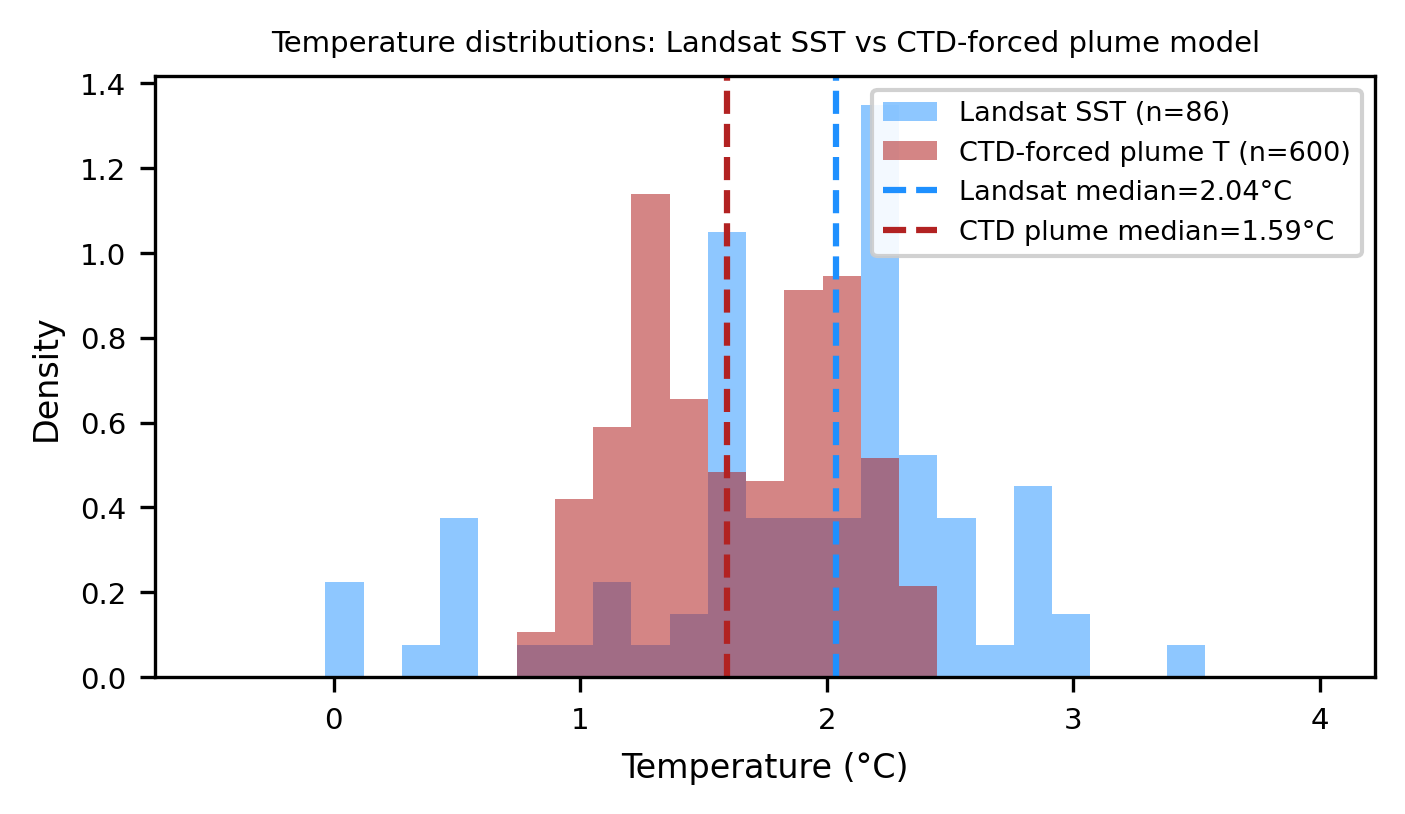

Saved: c:\Users\s1834371\OneDrive - University of Edinburgh\CHAPTER 2\pre-submission_PLUME_WORK\landsat-plume-proxy-revision_ROUND2\figures\STORE_CTD_plume_temp_distribution.png


In [86]:
all_ctd_surf_T = np.concatenate([r['surf_T'] for r in ctd_results])

fig_w_mm, fig_h_mm = 120, 70
inch = 0.0393701
fig, ax = plt.subplots(figsize=(fig_w_mm * inch, fig_h_mm * inch), dpi=300)

bins = np.linspace(-0.5, 4.0, 30)
ax.hist(landsat_df['SST_median'], bins=bins, color='dodgerblue', alpha=0.5, edgecolor='none',
        label=f'Landsat SST (n={len(landsat_df)})', density=True)
ax.hist(all_ctd_surf_T, bins=bins, color='firebrick', alpha=0.55, edgecolor='none',
        label=f'CTD-forced plume T (n={len(all_ctd_surf_T)})', density=True)

lsst = landsat_df['SST_median'].values
ax.axvline(np.median(lsst), color='dodgerblue', linewidth=1.5, linestyle='--',
           label=f'Landsat median={np.median(lsst):.2f}°C')
ax.axvline(np.median(all_ctd_surf_T), color='firebrick', linewidth=1.5, linestyle='--',
           label=f'CTD plume median={np.median(all_ctd_surf_T):.2f}°C')

ax.set_xlabel('Temperature (°C)', fontsize=8)
ax.set_ylabel('Density', fontsize=8)
ax.tick_params(labelsize=7)
ax.legend(fontsize=6.5, framealpha=0.9)
ax.set_title('Temperature distributions: Landsat SST vs CTD-forced plume model', fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'STORE_CTD_plume_temp_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'STORE_CTD_plume_temp_distribution.png'}")

## 7. Per-CTD Cast Ensemble Plots

One panel per accepted CTD cast, replicating the layout of `get_STORE_CTD_comparisons.ipynb`:
- **Grey lines**: individual ensemble plume temperature profiles (α=0.95, lw=0.2)
- **Black dashed**: ensemble mean plume profile
- **Blue solid/dotted**: CTD ambient temperature (solid = measured, dotted = extension to GL depth)
- **Right strip**: CTD salinity profile
- **Orange dot + error bar**: nearest Landsat SST observation at z = 0

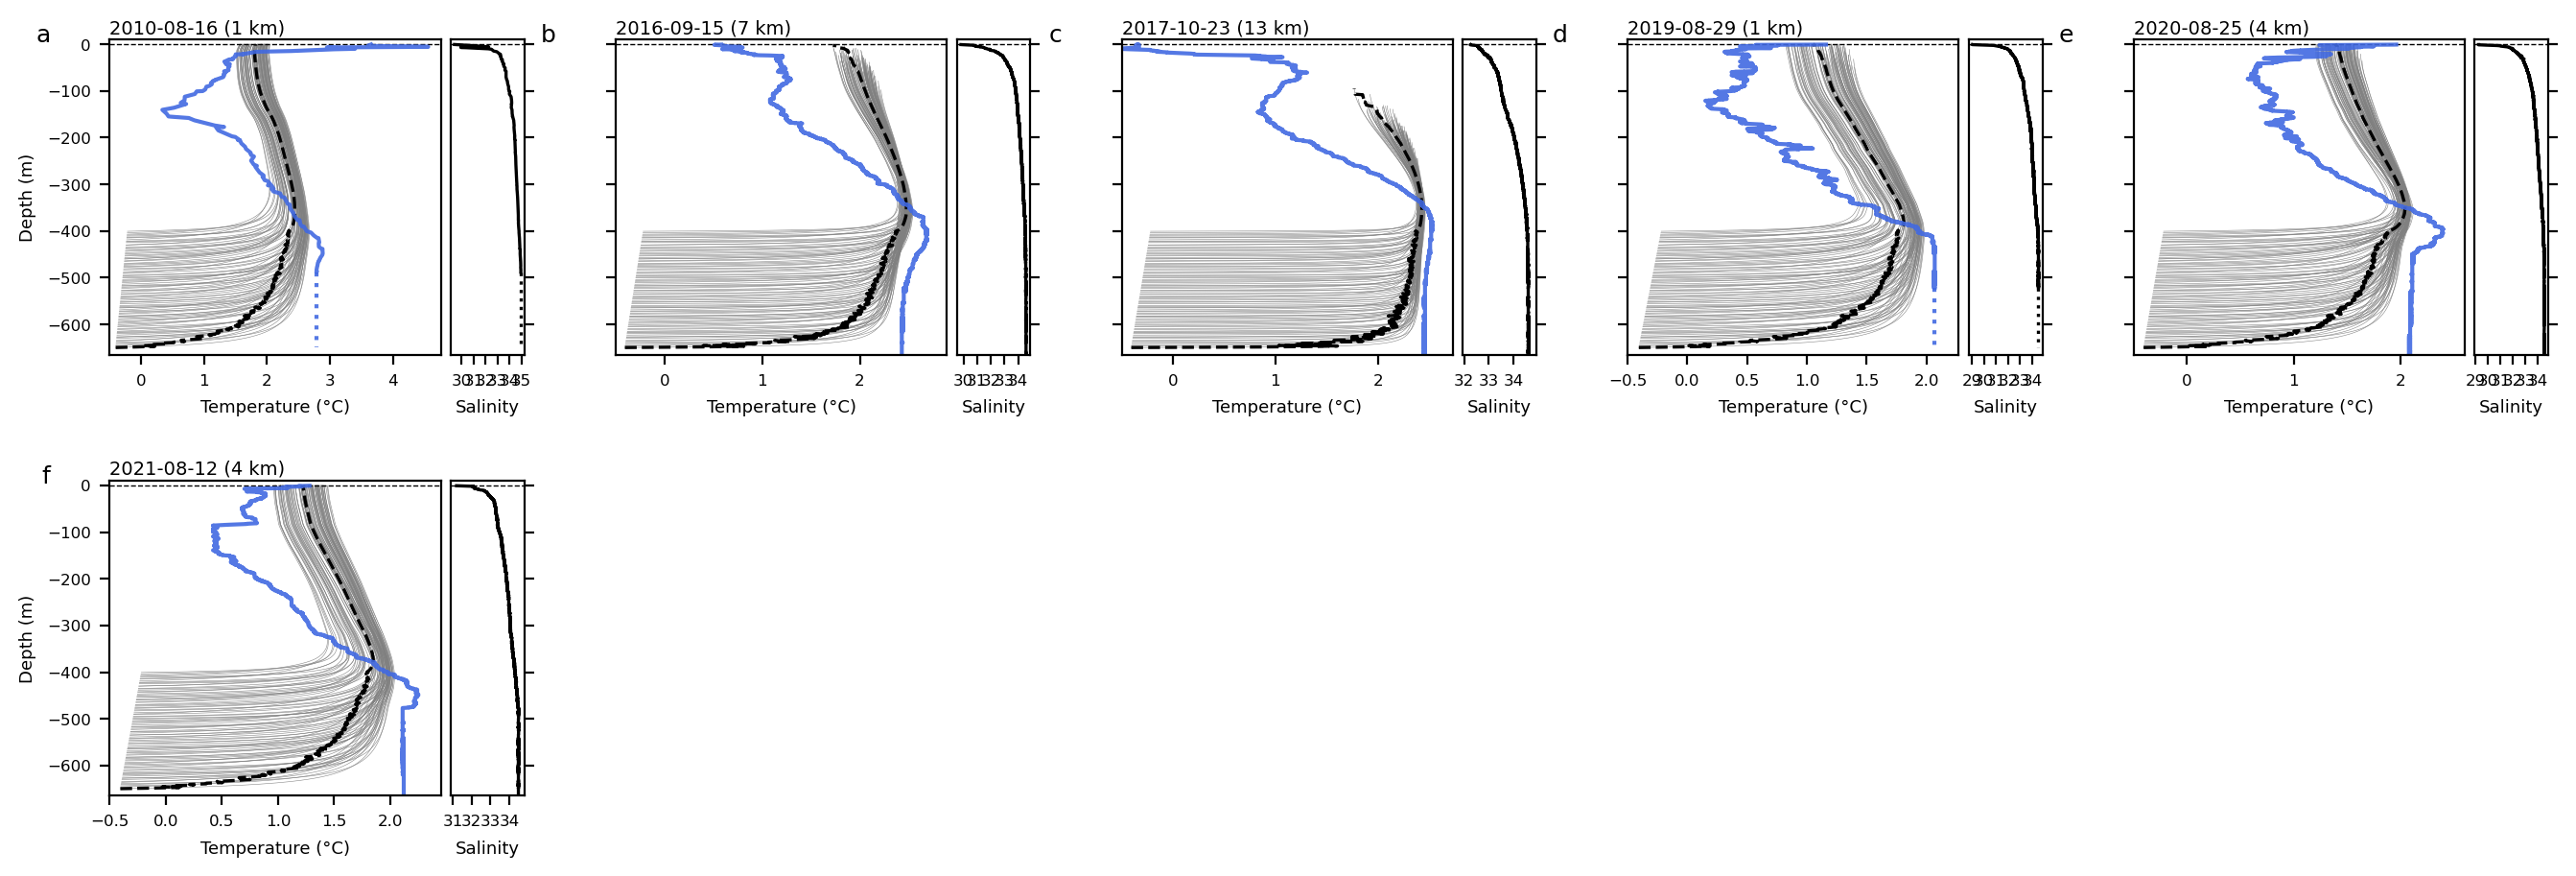

Saved: c:\Users\s1834371\OneDrive - University of Edinburgh\CHAPTER 2\pre-submission_PLUME_WORK\landsat-plume-proxy-revision_ROUND2\figures\STORE_CTD_per_cast_plume_profiles.png


In [87]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import MultipleLocator

n = len(ctd_results)
n_cols = min(n, 5)
n_rows = (n + n_cols - 1) // n_cols

panel_w_mm = 250 / 3
fig_w_mm   = panel_w_mm * n_cols
fig_h_mm   = 65 * n_rows
inch       = 0.0393701

fig = plt.figure(figsize=(fig_w_mm * inch, fig_h_mm * inch), dpi=200)
gs_outer = GridSpec(n_rows, n_cols, figure=fig, wspace=0.22, hspace=0.40)
subplot_labels = 'abcdefghijklmnopqrstuvwxyz'

for i, r in enumerate(ctd_results):
    row = i // n_cols; col = i % n_cols
    gs_inner = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_outer[row, col],
                                       width_ratios=[4.5, 1], wspace=0.05)
    ax1 = fig.add_subplot(gs_inner[0, 0])
    ax2 = fig.add_subplot(gs_inner[0, 1])

    prof      = all_ctd_profiles[r['ctd_idx']]
    raw_depth = prof['depth']; raw_temp = prof['temp']; raw_sal = prof['sal']
    ext_depth = r['ext_depth']; ext_temp = r['ext_temp']; ext_sal = r['ext_sal']

    all_T_flat = np.concatenate(r['T_profiles'])
    xmin = max(min(raw_temp.min(), all_T_flat.min()) - 0.15, -0.5)
    xmax = max(raw_temp.max(), all_T_flat.max(), r['T_p90']) + 0.2

    for T_prof, z_prof in zip(r['T_profiles'], r['z_profiles']):
        ax1.plot(T_prof, z_prof, color='grey', alpha=0.95, linewidth=0.2)

    z_deep   = min(zp.min() for zp in r['z_profiles'])
    z_shal   = max(zp.max() for zp in r['z_profiles'])
    z_common = np.linspace(z_deep, z_shal, 500)
    T_at_z = np.full((len(r['T_profiles']), len(z_common)), np.nan)
    for j, (T_prof, z_prof) in enumerate(zip(r['T_profiles'], r['z_profiles'])):
        in_range = (z_common >= z_prof.min()) & (z_common <= z_prof.max())
        if in_range.any():
            T_at_z[j, in_range] = np.interp(z_common[in_range], z_prof, T_prof)
    T_mean = np.nanmean(T_at_z, axis=0)
    valid  = ~np.isnan(T_mean)
    ax1.plot(T_mean[valid], z_common[valid], color='k', linestyle='--', linewidth=1.2)

    ax1.hlines(0, xmin, xmax, color='k', linestyle='--', linewidth=0.5)
    ax1.plot(raw_temp, -raw_depth, color='royalblue', alpha=0.9, linewidth=1.5, linestyle='-')
    if ext_depth[-1] > raw_depth[-1]:
        ax1.plot([raw_temp[-1], ext_temp[-1]], [-raw_depth[-1], -ext_depth[-1]],
                 color='royalblue', alpha=0.9, linewidth=1.5, linestyle='dotted')

    ax2.plot(raw_sal, -raw_depth, color='k', linewidth=1.2, linestyle='-')
    if ext_depth[-1] > raw_depth[-1]:
        ax2.plot([raw_sal[-1], ext_sal[-1]], [-raw_depth[-1], -ext_depth[-1]],
                 color='k', linewidth=1.2, linestyle=':')
    s_min = raw_sal.min() - 0.3; s_max = raw_sal.max() + 0.3
    ax2.hlines(0, s_min, s_max, color='k', linestyle='--', linewidth=0.5)

    y_bot = -(ext_depth[-1] + 15)
    ax1.set_xlim(xmin, xmax); ax1.set_ylim(y_bot, 10)
    ax2.set_ylim(ax1.get_ylim()); ax2.set_xlim(s_min, s_max)
    ax2.xaxis.set_major_locator(MultipleLocator(1))
    ax1.set_xlabel('Temperature (°C)', fontsize=6.5)
    ax2.set_xlabel('Salinity', fontsize=6.5)
    ax1.tick_params(labelsize=6); ax2.tick_params(labelsize=6)
    ax2.yaxis.tick_right(); ax2.yaxis.set_label_position('right')
    if col == 0:
        ax1.set_ylabel('Depth (m)', fontsize=6.5)
    else:
        ax1.set_yticklabels([])
    ax2.set_yticklabels([]); ax2.set_ylabel('')

    ax1.text(-0.18, 1.05, subplot_labels[i], transform=ax1.transAxes, fontsize=9, va='top', ha='right')
    dist_km = prof.get('dist_km') or haversine_km(prof['lat'], prof['lon'], STORE_LAT_REF, STORE_LON_REF)
    ax1.set_title(f"{r['date'].strftime('%Y-%m-%d')} ({dist_km:.0f} km)", fontsize=7, loc='left', y=0.97)

plt.savefig(FIGURES_DIR / 'STORE_CTD_per_cast_plume_profiles.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'STORE_CTD_per_cast_plume_profiles.png'}")